# Домашнее задание 2. StarGAN


P.S. версия по старому дедлайну. Удачность: 12 %

## Этап 1. Установка зависимостей, инициализация и загрузка данных

В этом разделе мы работаем с датасетом CelebA, содержащим изображения лиц с набором атрибутов. Целью задания является генерация новых изображений лиц с заданными характеристиками.

In [1]:
%pip install lpips -q

import sys
sys.path.append('../../seminars/utils/')  # Добавляем путь к CelebADataset

import torch
from lpips import LPIPS
from torchvision import transforms
from munch import Munch
from tqdm.auto import trange
import matplotlib.pyplot as plt
import numpy as np
from datasets.celeba import CelebADataset

device: str = 'cuda:3' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device(device)

/bin/bash: /opt/miniconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Note: you may need to restart the kernel to use updated packages.


In [2]:
args = Munch()
args.img_size = 256  # Размер изображений после преобразования

# Создание последовательности преобразований для подготовки изображений
transform=transforms.Compose([
    transforms.Resize(args.img_size),
    transforms.CenterCrop(args.img_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

# Загрузка датасета CelebA с применением указанных преобразований
# celeba = CelebADataset(
#     root_dir='./data/celeba',
#     transform=transform
# )

# Число потоков для загрузки данных
num_workers = 0 if device.type == 'cuda' else 2
# Whether to put fetched data tensors to pinned memory
pin_memory = True if device.type == 'cuda' else False

# args.batch_size = ...   # Задайте размер батча
args.batch_size = 32

# Создание DataLoader
# dataloader = torch.utils.data.DataLoader(
#     celeba,
#     batch_size=args.batch_size,
#     num_workers=num_workers,
#     pin_memory=pin_memory,
#     shuffle=True
# )


### Подумаем

Заметим, что изображение в нашем случае имеет несколько атрибутов, которые мы рассматриваем, как домены в рамках данного задания. Нужно научиться с этим работать.

*Идея1.*
Пусть доменами будут комбинации атрибутов. Звучит прикольно, но в нашей задаче это 2 ^ 40 линейных слоев. Можно ограничить количество используемых доменов, выбрать штук  5 самых интересных комбинаций, а все остальных записать в домен "Trash". Звучит сомнительно, да и выборка изображений по комбинации доменов небольшая, наши сети (генератор, мапер, стайлэнкодер) скорее не смогут выучить ничего дельного + сама идея мне не импонирует.

*Идея2.*
StarGAN работает с парами (референс, домен). Давайте отдельно рассматривать Бреда Пита(x) с мощным подбородком(y_1) и Бреда Пита(x) с шикарными бровями(y_2). Скорее всего наш генероатор успешно научится использовать стили (s_1, s_2). Мы даже можем поэкспериментировать с комбинированием стилей путем последовательного применения генератора: G(G(x, s_1), s_2), где s_1 это стайл код мощного подбородка, а s_2 - стайл код шикарных бровей.

*Вывод*. 
Идея2 выглядит более перспективно, попробую проверить ее в перую очередь, остальные предположения по мере сил и времени.

### Датасет для Идеи2

Пришлось попыхтеть, чтобы переиспользовать CelebADataset и сделать все оптимально

In [3]:
import torch


class StarCeleba(CelebADataset):
    """
    Адаптированный Dataset для StarGAN, основанный на CelebADataset.
    Возвращает пары (изображение, домен) для каждой положительной метки (1),
    переопределяя только метод __getitem__.
    """

    def __init__(self, root_dir: str = "../data/celeba", transform=None):
        super().__init__(root_dir=root_dir, transform=transform)

        # Подсчет положительных меток для каждого изображения
        self.labels = torch.stack(list(self.attr_map.values()))
        self.positive_counts = (self.labels == 1).sum(dim=1)
        self.total_positive = self.positive_counts.sum()

        # Кумулятивные суммы для быстрого доступа
        self.cumulative_counts = torch.cumsum(self.positive_counts, dim=0)

    def __len__(self):
        return self.total_positive.item()

    def __getitem__(self, idx):
        """
        Возвращает:
            - image (Tensor): Преобразованное изображение
            - domain_idx (int): Индекс домена (атрибута)
            - domain_name (str): Название домена
            - all_labels (Tensor): Все метки изображения
        """
        # Находим изображение по глобальному индексу
        img_idx = torch.searchsorted(self.cumulative_counts, idx, right=True).item()
        offset = idx - (self.cumulative_counts[img_idx - 1].item() if img_idx > 0 else 0)

        # Ищем индекс домена для текущего изображения
        positive_domains = torch.where(self.labels[img_idx] == 1)[0]
        domain_idx = positive_domains[offset].item()

        # Используем оригинальный __getitem__ для загрузки изображения и меток
        image, default_info_dict = super().__getitem__(img_idx)
        info_dict = {
            "domain_name": self.header[domain_idx],
            "domain_idx": domain_idx,
            "attributes": default_info_dict["attributes"],
        }

        return image, info_dict

In [4]:
# Загрузка датасета CelebA с применением указанных преобразований
star_celeba = StarCeleba(
    root_dir='./data/celeba',
    transform=transform
)

# Создание DataLoader
star_dataloader = torch.utils.data.DataLoader(
    star_celeba,
    batch_size=args.batch_size,
    num_workers=num_workers,
    pin_memory=pin_memory,
    shuffle=True
)


### Визуализация датасета

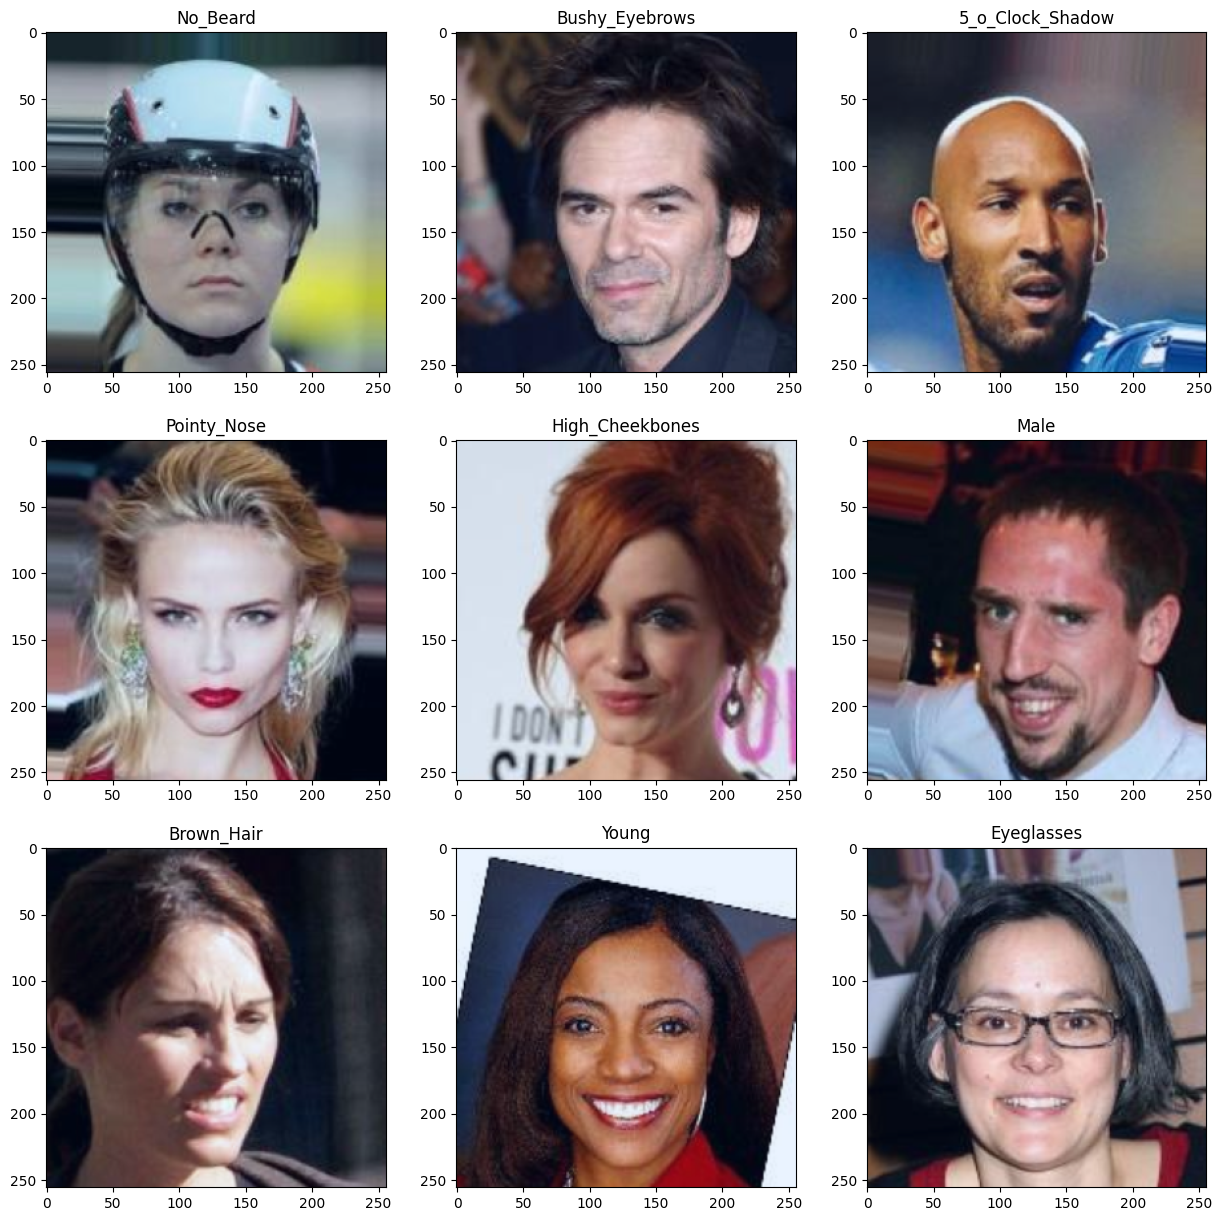

In [5]:
# Визуализация случайно выбранных изображений из датасета

_, axes = plt.subplots(ncols=3, nrows=3, figsize=(15, 15))
for i, img_idx in enumerate(np.random.choice(range(len(star_celeba)), 9)):

    img, info = star_celeba[img_idx]
    img = (img - img.min()) / (img.max() - img.min())
    axes[i // 3][i % 3].set_title(info["domain_name"], fontsize=12)
    axes[i // 3][i % 3].imshow(img.detach().cpu().numpy().transpose(1, 2, 0))

## Этап 2. Инициализация и обучение модели

В этом этапе необходимо реализовать и обучить модель StarGAN для генерации лиц с заданными атрибутами.

Вы можете выбрать одну из следующих моделей:
- [StarGANv1](https://arxiv.org/pdf/1711.09020.pdf) (**до 4 баллов**)
- [StarGANv2](https://arxiv.org/abs/1912.01865) (**до 7 баллов**) ✅

### Давайте имплементуруем StarGANv2

In [6]:
import torch.nn as nn
import torch.functional as F

In [7]:
class ResBlk(nn.Module):
    def __init__(self, dim_in, dim_out, actv=nn.LeakyReLU(0.2),
                 normalize=False, downsample=False):
        super().__init__()
        self.actv = actv
        self.normalize = normalize
        self.downsample = downsample
        self.learned_sc = dim_in != dim_out
        self._build_weights(dim_in, dim_out)

    def _build_weights(self, dim_in, dim_out):
        self.conv1 = nn.Conv2d(dim_in, dim_in, 3, 1, 1)
        self.conv2 = nn.Conv2d(dim_in, dim_out, 3, 1, 1)
        if self.normalize:
            self.norm1 = nn.InstanceNorm2d(dim_in, affine=True)
            self.norm2 = nn.InstanceNorm2d(dim_in, affine=True)
        if self.learned_sc:
            self.conv1x1 = nn.Conv2d(dim_in, dim_out, 1, 1, 0, bias=False)

    def _shortcut(self, x):
        if self.learned_sc:
            x = self.conv1x1(x)
        if self.downsample:
            x = F.avg_pool2d(x, 2)
        return x

    def _residual(self, x):
        if self.normalize:
            x = self.norm1(x)
        x = self.actv(x)
        x = self.conv1(x)
        if self.downsample:
            x = F.avg_pool2d(x, 2)
        if self.normalize:
            x = self.norm2(x)
        x = self.actv(x)
        x = self.conv2(x)
        return x

    def forward(self, x):
        x = self._shortcut(x) + self._residual(x)
        return x / np.sqrt(2)  # unit variance


In [8]:
class AdaIN(nn.Module):
    def __init__(self, style_dim, num_features):
        super().__init__()
        self.norm = nn.InstanceNorm2d(num_features, affine=False)
        self.fc = nn.Linear(style_dim, num_features*2)

    def forward(self, x, s):
        h = self.fc(s)
        h = h.view(h.size(0), h.size(1), 1, 1)
        gamma, beta = torch.chunk(h, chunks=2, dim=1)
        return (1 + gamma) * self.norm(x) + beta

In [ ]:
class AdainResBlk(nn.Module):
    def __init__(self, dim_in, dim_out, style_dim=64, w_hpf=0,
                 actv=nn.LeakyReLU(0.2), upsample=False):
        super().__init__()
        self.w_hpf = w_hpf
        self.actv = actv
        self.upsample = upsample
        self.learned_sc = dim_in != dim_out
        self._build_weights(dim_in, dim_out, style_dim)

    def _build_weights(self, dim_in, dim_out, style_dim=64):
        self.conv1 = nn.Conv2d(dim_in, dim_out, 3, 1, 1)
        self.conv2 = nn.Conv2d(dim_out, dim_out, 3, 1, 1)
        self.norm1 = AdaIN(style_dim, dim_in)
        self.norm2 = AdaIN(style_dim, dim_out)
        if self.learned_sc:
            self.conv1x1 = nn.Conv2d(dim_in, dim_out, 1, 1, 0, bias=False)

    def _shortcut(self, x):
        if self.upsample:
            x = F.interpolate(x, scale_factor=2, mode='nearest')
        if self.learned_sc:
            x = self.conv1x1(x)
        return x

    def _residual(self, x, s):
        x = self.norm1(x, s)
        x = self.actv(x)
        if self.upsample:
            x = F.interpolate(x, scale_factor=2, mode='nearest')
        x = self.conv1(x)
        x = self.norm2(x, s)
        x = self.actv(x)
        x = self.conv2(x)
        return x

    def forward(self, x, s):
        out = self._residual(x, s)
        return out

In [ ]:
class Generator(nn.Module):
    def __init__(self, img_size=256, style_dim=64, max_conv_dim=512, w_hpf=1):
        super().__init__()
        dim_in = 2**14 // img_size
        self.img_size = img_size
        self.from_rgb = nn.Conv2d(3, dim_in, 3, 1, 1)
        self.encode = nn.ModuleList()
        self.decode = nn.ModuleList()
        self.to_rgb = nn.Sequential(
            nn.InstanceNorm2d(dim_in, affine=True),
            nn.LeakyReLU(0.2),
            nn.Conv2d(dim_in, 3, 1, 1, 0))

        repeat_num = int(np.log2(img_size)) - 4
        if w_hpf > 0:
            repeat_num += 1
        for _ in range(repeat_num):
            dim_out = min(dim_in*2, max_conv_dim)
            self.encode.append(
                ResBlk(dim_in, dim_out, normalize=True, downsample=True))
            self.decode.insert(
                0, AdainResBlk(dim_out, dim_in, style_dim,
                               w_hpf=w_hpf, upsample=True))  # stack-like
            dim_in = dim_out

        for _ in range(2):
            self.encode.append(
                ResBlk(dim_out, dim_out, normalize=True))
            self.decode.insert(
                0, AdainResBlk(dim_out, dim_out, style_dim, w_hpf=w_hpf))


    def forward(self, x, s, masks=None):
        x = self.from_rgb(x)
        cache = {}
        for block in self.encode:
            if (masks is not None) and (x.size(2) in [32, 64, 128]):
                cache[x.size(2)] = x
            x = block(x)
        for block in self.decode:
            x = block(x, s)
            if (masks is not None) and (x.size(2) in [32, 64, 128]):
                mask = masks[0] if x.size(2) in [32] else masks[1]
                mask = F.interpolate(mask, size=x.size(2), mode='bilinear')
                x = x + self.hpf(mask * cache[x.size(2)])
        return self.to_rgb(x)

In [11]:
class MappingNetwork(nn.Module):
    def __init__(self, latent_dim=16, style_dim=64, num_domains=2):
        super().__init__()
        layers = []
        layers += [nn.Linear(latent_dim, 512)]
        layers += [nn.ReLU()]
        for _ in range(3):
            layers += [nn.Linear(512, 512)]
            layers += [nn.ReLU()]
        self.shared = nn.Sequential(*layers)

        self.unshared = nn.ModuleList()
        for _ in range(num_domains):
            self.unshared += [nn.Sequential(nn.Linear(512, 512),
                                            nn.ReLU(),
                                            nn.Linear(512, 512),
                                            nn.ReLU(),
                                            nn.Linear(512, 512),
                                            nn.ReLU(),
                                            nn.Linear(512, style_dim))]

    def forward(self, z, y):
        h = self.shared(z)
        out = []
        for layer in self.unshared:
            out += [layer(h)]
        out = torch.stack(out, dim=1)  # (batch, num_domains, style_dim)
        idx = torch.LongTensor(range(y.size(0))).to(y.device)
        s = out[idx, y]  # (batch, style_dim)
        return s



In [12]:
class StyleEncoder(nn.Module):
    def __init__(self, img_size=256, style_dim=64, num_domains=2, max_conv_dim=512):
        super().__init__()
        dim_in = 2**14 // img_size
        blocks = []
        blocks += [nn.Conv2d(3, dim_in, 3, 1, 1)]

        repeat_num = int(np.log2(img_size)) - 2
        for _ in range(repeat_num):
            dim_out = min(dim_in*2, max_conv_dim)
            blocks += [ResBlk(dim_in, dim_out, downsample=True)]
            dim_in = dim_out

        blocks += [nn.LeakyReLU(0.2)]
        blocks += [nn.Conv2d(dim_out, dim_out, 4, 1, 0)]
        blocks += [nn.LeakyReLU(0.2)]
        self.shared = nn.Sequential(*blocks)

        self.unshared = nn.ModuleList()
        for _ in range(num_domains):
            self.unshared += [nn.Linear(dim_out, style_dim)]

    def forward(self, x, y):
        h = self.shared(x)
        h = h.view(h.size(0), -1)
        out = []
        for layer in self.unshared:
            out += [layer(h)]
        out = torch.stack(out, dim=1)  # (batch, num_domains, style_dim)
        idx = torch.LongTensor(range(y.size(0))).to(y.device)
        s = out[idx, y]  # (batch, style_dim)
        return s

In [13]:
class Discriminator(nn.Module):
    def __init__(self, img_size=256, num_domains=2, max_conv_dim=512):
        super().__init__()
        dim_in = 2**14 // img_size
        blocks = []
        blocks += [nn.Conv2d(3, dim_in, 3, 1, 1)]

        repeat_num = int(np.log2(img_size)) - 2
        for _ in range(repeat_num):
            dim_out = min(dim_in*2, max_conv_dim)
            blocks += [ResBlk(dim_in, dim_out, downsample=True)]
            dim_in = dim_out

        blocks += [nn.LeakyReLU(0.2)]
        blocks += [nn.Conv2d(dim_out, dim_out, 4, 1, 0)]
        blocks += [nn.LeakyReLU(0.2)]
        blocks += [nn.Conv2d(dim_out, num_domains, 1, 1, 0)]
        self.main = nn.Sequential(*blocks)

    def forward(self, x, y):
        out = self.main(x)
        out = out.view(out.size(0), -1)  # (batch, num_domains)
        idx = torch.LongTensor(range(y.size(0))).to(y.device)
        out = out[idx, y]  # (batch)
        return out


### Инициализация

Ниже приведён шаблон для определения основных компонентов модели. Реализуйте их по своему усмотрению.

In [14]:
# def build_model(args: Munch):
#     generator = nn.DataParallel(Generator(args.img_size, args.style_dim, w_hpf=args.w_hpf))
#     mapping_network = nn.DataParallel(MappingNetwork(args.latent_dim, args.style_dim, args.num_domains))
#     style_encoder = nn.DataParallel(StyleEncoder(args.img_size, args.style_dim, args.num_domains))
#     discriminator = nn.DataParallel(Discriminator(args.img_size, args.num_domains))

#     nets = Munch(generator=generator,
#                  mapping_network=mapping_network,
#                  style_encoder=style_encoder,
#                  discriminator=discriminator)


#     return nets

### Добавим рисовалку

In [15]:
import torchvision.transforms.functional as transforms_F

def show(imgs: torch.Tensor):
    fix, axs = plt.subplots(ncols=len(imgs), squeeze=False)
    for i, img in enumerate(imgs):
        img = img.detach()
        img = transforms_F.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

### Обучение

In [16]:
args.style_dim=64
args.num_domains = 40
args.latent_dim=16

args.lr=0.0001
args.beta1=0.0
args.beta2=0.99

args.num_epochs = 1
# args.lambda_sty = 1   # пока не буим трогать, в статье все единички
# args.lambda_ds = 1
# args.lambda_cyc = 1

args.log_step = 5
# args.log_dir = 'tlogs'
args.checkpoint_dir = './checkpoints'
args.checkpoint_step = 3000

In [17]:
def get_test_set(dataset: StarCeleba, num_samples: int, num_domains: int) -> tuple[torch.Tensor, torch.Tensor]:

    idxs = torch.randperm(len(dataset))[:num_samples]
    subset = [dataset[idx] for idx in idxs]
    
    imgs = torch.stack([img for (img, _ ) in subset])

    domain_idxs = torch.randint(0, num_domains, (num_samples,))


    return imgs, domain_idxs

In [18]:
test_set = get_test_set(star_celeba, 5, 40)

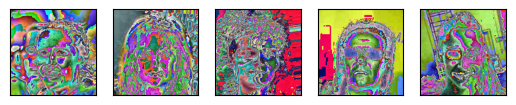

In [19]:
show(test_set[0])

In [ ]:
import os
import torch
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
from torchvision.utils import make_grid
from IPython.display import clear_output


class Solver:
    def __init__(self, config: Munch, device, dataloader, test_set = None):
        self.config = config
        self.device = device
        self.dataloader = dataloader
        self.test_set = test_set

        self.build_model()

        self.optimizer_g = torch.optim.Adam(self.generator.parameters(), lr=config.lr, betas=(config.beta1, config.beta2))
        self.optimizer_d = torch.optim.Adam(self.discriminator.parameters(), lr=config.lr, betas=(config.beta1, config.beta2))

        self.writer = SummaryWriter()

    def build_model(self):
        self.generator =  Generator(self.config.img_size, self.config.style_dim, self.config.num_domains).to(self.device)
        self.discriminator =  Discriminator(self.config.img_size, self.config.num_domains).to(self.device)
        self.mapping_network =  MappingNetwork(self.config.latent_dim, self.config.style_dim, self.config.num_domains).to(self.device)
        self.style_encoder =  StyleEncoder(self.config.img_size, self.config.style_dim, self.config.num_domains).to(self.device)
    
    def sample_images(self, x_real, y_to):
        self.generator.eval()
        with torch.no_grad():
            y_to = y_to.to(self.device)
            x_real = x_real.to(self.device)

            z = torch.randn(x_real.size(0), self.config.latent_dim).to(self.device)
            s = self.mapping_network(z, y_to)
            x_fake = self.generator(x_real, s)

            img_grid = make_grid(torch.cat([x_real, x_fake], dim=0), nrow=x_real.size(0), normalize=True, scale_each=True)

            return x_fake, img_grid
    
    def save_checkpoint(self, epoch, step):
        checkpoint_path = os.path.join("./checkpoints", f"checkpoint_epoch_{epoch}_step_{step}.pth")
        torch.save({
            'epoch': epoch,
            'step': step,
            'generator_state_dict': self.generator.state_dict(),
            'discriminator_state_dict': self.discriminator.state_dict(),
            'mapping_network_state_dict': self.mapping_network.state_dict(),
            'style_encoder_state_dict': self.style_encoder.state_dict(),
            'optimizer_g_state_dict': self.optimizer_g.state_dict(),
            'optimizer_d_state_dict': self.optimizer_d.state_dict()
        }, checkpoint_path)
    
    def load_checkpoint(self, checkpoint_path):
        if os.path.isfile(checkpoint_path):
            checkpoint = torch.load(checkpoint_path, map_location=self.device)
            self.generator.load_state_dict(checkpoint['generator_state_dict'])
            self.discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
            self.mapping_network.load_state_dict(checkpoint['mapping_network_state_dict'])
            self.style_encoder.load_state_dict(checkpoint['style_encoder_state_dict'])
            self.optimizer_g.load_state_dict(checkpoint['optimizer_g_state_dict'])
            self.optimizer_d.load_state_dict(checkpoint['optimizer_d_state_dict'])


    def train(self):
        for epoch in range(self.config.num_epochs):
            self.train_epoch(self.dataloader, epoch)
        self.writer.close()

    def train_epoch(self, data_loader, epoch):
        self.generator.train()
        self.discriminator.train()

        pbar = tqdm(enumerate(data_loader), total=len(self.dataloader))
        for i, (x_real, info) in pbar:
            global_step = epoch * len(data_loader) + i


            x_real = x_real.to(self.device)
            y_org = info["domain_idx"].to(self.device)

            # Обучение дискриминатора
            z = torch.randn(x_real.size(0), self.config.latent_dim).to(self.device)
            with torch.no_grad():
                s = self.mapping_network(z, y_org)
                x_fake = self.generator(x_real, s)
            out_real = self.discriminator(x_real, y_org)
            out_fake = self.discriminator(x_fake, y_org)
            d_loss_real = F.binary_cross_entropy_with_logits(out_real, torch.ones_like(out_real))
            d_loss_fake = F.binary_cross_entropy_with_logits(out_fake, torch.zeros_like(out_fake))
            d_loss = d_loss_real + d_loss_fake
            self.optimizer_d.zero_grad()
            d_loss.backward()
            self.optimizer_d.step()
            
            # Обучение генератора
            z = torch.randn(x_real.size(0), self.config.latent_dim).to(self.device)
            s = self.mapping_network(z, y_org)
            x_fake = self.generator(x_real, s)
            out_fake = self.discriminator(x_fake, y_org)
            g_loss = F.binary_cross_entropy_with_logits(out_fake, torch.ones_like(out_fake))
            self.optimizer_g.zero_grad()
            g_loss.backward()
            self.optimizer_g.step()

            global_step = epoch * len(data_loader) + i
            self.writer.add_scalar('Loss/Discriminator', d_loss.item(), global_step)
            self.writer.add_scalar('Loss/Generator', g_loss.item(), global_step)

            log = f"E{epoch}, D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}"
            
            pbar.set_description(log)


            if (i + 1) % self.config.log_step == 0:
                if self.test_set:
                    _, grid = self.sample_images(
                        self.test_set[0],
                        self.test_set[1]
                    )
                    # пусть все будет в тензорборде, в юпитере вывод изображений съедается
                    self.writer.add_image(f'sampled_test_epoch_{epoch}', grid, global_step=global_step)

            if global_step % self.config.checkpoint_step == 0:
                self.save_checkpoint(epoch, global_step)


In [21]:
solver = Solver(args, device, star_dataloader, test_set)

In [22]:
torch.cuda.empty_cache()

### Оценка модели

Для оценки качества сгенерированных изображений используется метрика LPIPS.

In [29]:
lpips = LPIPS()

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/byzovti/.conda/envs/genmod0/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/byzovti/.conda/envs/genmod0/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/byzovti/.local/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


In [ ]:
test_iters = 100  # Количество итераций для тестирования модели
values = []


for i in trange(test_iters):
    x_real, _ = next(iter(star_dataloader))
    x_ref, _ = next(iter(star_dataloader))
    x_ref2, _ = next(iter(star_dataloader))
    
    batch_size = x_real.shape[0]
    
    # Случайное задание целевого и исходного доменов для каждого изображения
    y_trg = torch.tensor(np.random.choice(np.arange(args.num_domains), size=batch_size))  # Целевой домен
    y_org = torch.tensor(np.random.choice(np.arange(args.num_domains), size=batch_size))  # Исходный домен
    
    # Перенос данных на выбранное устройство и приведение типов
    x_real, x_ref, x_ref2 = [x.to(device).float() for x in [x_real, x_ref, x_ref2]]
    y_trg, y_org = [x.to(device).long() for x in [y_trg, y_org]]
    
    # Генерация изображения с использованием вашей модели
    x_fake, _ = solver.sample_images(x_ref, y_trg)
    
    # Вычисление LPIPS между сгенерированным и реальным изображением
    values.extend(lpips(x_fake.cpu(), x_real.cpu()).squeeze().detach().tolist())

print("Среднее значение LPIPS:", np.mean(values))
assert np.mean(values) < 1.3

  0%|          | 0/5 [00:00<?, ?it/s]

Среднее значение LPIPS: 0.6734698262065649


### Вывод результатов оценки

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.7516255..2.7892008].


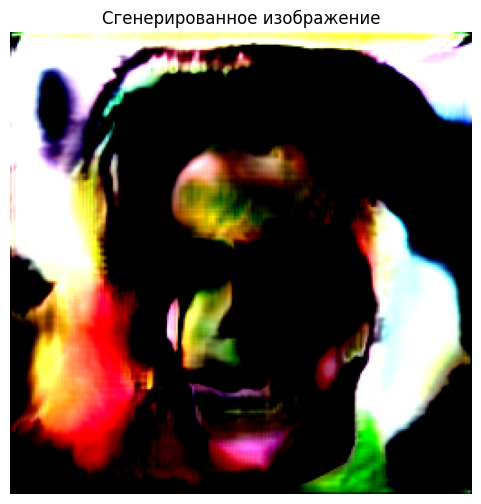

In [41]:
with torch.no_grad():
    z_trg = torch.randn((batch_size, args.latent_dim)).to(device)
    s_trg = solver.mapping_network(z_trg, y_trg)
    s_trg = solver.style_encoder(x_ref2, y_trg) 
    x_fake = solver.generator(x_real, s_trg)

plt.figure(figsize=(6, 6))
plt.imshow(x_fake[12].permute(1, 2, 0).detach().cpu().numpy())
plt.title("Сгенерированное изображение")
plt.axis('off')
plt.show()


Мое мнение на этот счет:
![image.png](./attachments/mr_exceptional_sad.png)


Что то явно пошло не так и на это ушло 24 часа. Как подсказали коллеги, можно было подрезать глубину сети и разрешеие изображений для оптимизации алгоритма на этапе отлова ошибок.

Давайте глянем на лоссы, которые я выводил для обучения. 

![image.png](./attachments/primary_run_losses.png)

Заметил, для полного анализа не хватает отдельных компонент (adv, sty, cyc). На том, что имеется, можно заметить неладное - лосс генератора растет, а дискриминатора наоборот падает, для успешного обучения картина должна быть другой. В нашем случае, как минимум, дискриминатор через чур хорошо отсекал фейки.

Хвататься за идею об отдельном домене для каждого признака тоже было глупо, датасет раздувается в разы, а результата 0. Скорее всего нужно было учиться на двух полах, как в оригинальной статье... но уже поздняк.


## Этап 3. Дополнительный анализ

В данном разделе рекомендуется провести дополнительные эксперименты и анализ:
- **Анализ латентного пространства**. *(2 балла)*
- **Текстовое ревью решения**: опишите, какие изменения можно внести для улучшения модели, и обоснуйте их. *(1 балл)*